# Notebook 2: Neural Optimization

Same workflow as notebook 1, but the analytical torque model is replaced
with a **neural torque model**: a small MLP that adds a learned residual
on top of the analytical torque, trained on measured data to absorb
saturation effects and other physics the closed-form expression misses.

The library's design makes this swap effectively a one-line change at the
model construction step — everything downstream (transform, optimizer,
grid sweep, plotting) is identical.

**What this notebook produces**

- `data/IEEETIE_machine2_compensated.pkl` — a dictionary of optimal DQ
  currents on the same `(torque, omega)` grid as notebook 1, but
  optimized against the neural model from scratch.
- A segments plot.

**Prerequisites**

- A trained NTM checkpoint at `weights/NTM_Weights.pth` plus its scaler
  at `weights/NTM_Scaler.npy`. Training the network is out of scope for
  this notebook (see `model_trainer.ipynb`).
- Notebook 1 is **not** required as input; notebooks 1 and 2 are siblings.

## 0. Imports and paths

In [7]:
import os
import pickle
import sys

import numpy as np
import torch

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
weights_dir = os.path.join(root_dir, "weights")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.parameters import Flux_IEEEMachine2, IEEEMachine2
from current_setpoints.simulation import Transform
from current_setpoints.optimization import (
    ModelNeural,
    MotorOptimizer,
    calculate_grid,
    grid_to_data,
)
from current_setpoints.utils.neural import load_neural_model
from current_setpoints.utils.plotting import plot_grid_segments

## 1. Machine, flux, transform

Identical to notebook 1. The neural model only changes what we plug in
at the torque-evaluation step; the machine physics, flux model, and
frame transform are exactly the same.

In [8]:
machine = IEEEMachine2()
NMAX = 1800  # mechanical RPM
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=NMAX)

flux = Flux_IEEEMachine2()
transform = Transform(machine=machine, flux=flux, add_volt_0=False)

## 2. Loading the trained neural network

`load_neural_model` reads two files: the PyTorch state dict (`.pth`)
with the network weights, and a NumPy archive (`.npy`) with the input
scaler's mean and scale. They must agree with the architecture
parameters `input_size` and `hidden_size` used during training.

For the IEEE benchmark machine 2, `input_size = 5` (one for `omega`,
four for the DQ currents `[d₁, q₁, d₃, q₃]`) and the hidden layer is 12
neurons wide.

> **Adapting to other phase counts.** `input_size = 1 + (n_phases − 1)`.
> A 7-phase machine would use 7, a 9-phase one 9. The weights file
> itself is machine-specific (the network is trained on a particular
> machine's measurements), so a different machine needs a separately
> trained checkpoint.

In [9]:
DEVICE = torch.device("cpu")

MODEL_SAVE_PATH = os.path.join(weights_dir, "NTM_Weights.pth")
SCALER_SAVE_PATH = os.path.join(weights_dir, "NTM_Scaler.npy")
INPUT_SIZE = 5
OPTIMAL_HIDDEN_SIZE = 12

print("Loading trained NeuralTorquePredictor...")
neural_net, scaler = load_neural_model(
    weights_path=MODEL_SAVE_PATH,
    scaler_path=SCALER_SAVE_PATH,
    hidden_size=OPTIMAL_HIDDEN_SIZE,
    input_size=INPUT_SIZE,
    device=DEVICE,
)

Loading trained NeuralTorquePredictor...


## 3. Neural torque model and optimizer

`ModelNeural` is the analytical model plus a learned residual. Its
`calculate_torque(omega, curr_dq)` method returns the sum of the
closed-form quadratic torque and the network's output, so from the
optimizer's perspective it behaves exactly like `ModelAnalytical` —
just with a slightly different torque surface.

The solver tolerances are looser than in notebook 1 (`ftol=1e-5`
instead of `1e-8`, `maxiter=2500` instead of `500`). The neural torque
surface is harder to optimize than the analytical one because the
network introduces non-smooth gradients; tight tolerances cause SLSQP
to thrash, so we trade some precision for convergence reliability.

In [10]:
neural_model = ModelNeural(
    machine=machine,
    flux=flux,
    neural_model=neural_net,
    scaler=scaler,
    device=DEVICE,
)

solver_opts_neural = {"disp": False, "ftol": 1e-5, "maxiter": 2500, "eps": 1e-4}
neural_optimizer = MotorOptimizer(model=neural_model, opts=solver_opts_neural)

## 4. Computing the compensated grid

"Compensated" here means: run the same `calculate_grid` sweep as in
notebook 1, but with the neural model and optimizer instead of the
analytical ones. The result is the neural model's view of what the
optimal current setpoints are at every operating point.

This is slower than the analytical grid because every SLSQP iteration
now includes a neural-network forward pass. Expect several minutes on
a CPU for a 201 × 201 grid.

> **Pickle safety.** If `data/IEEETIE_machine2_compensated.pkl`
> already exists, the cell loads it instead of recomputing — this
> protects you from accidentally overwriting a long-running result.
> To force a recompute, delete the file first.

In [11]:
grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}

filename = os.path.join(data_dir, "IEEETIE_machine2_compensated.pkl")

if os.path.isfile(filename):
    print(f"Loading existing compensated grid from '{filename}'...")
    with open(filename, "rb") as file:
        compensated_grid = pickle.load(file)
else:
    print("Computing compensated grid. This may take longer than the baseline...")
    compensated_grid = calculate_grid(
        optimizer=neural_optimizer,
        transform=transform,
        opts=grid_opts,
        mode="standard",
    )
    with open(filename, "wb") as file:
        pickle.dump(compensated_grid, file)
    print(f"Saved to '{filename}'.")

Loading existing compensated grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEEETIE_machine2_compensated.pkl'...


## 5. Visualizing the result

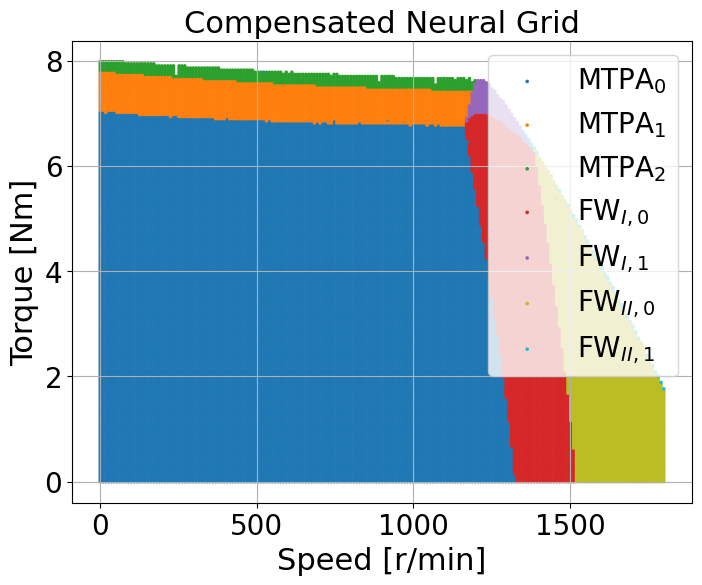

In [12]:
compensated_data = grid_to_data(compensated_grid, k_skip=1)
plot_grid_segments(compensated_data, title="Compensated Neural Grid")

## Next steps

The compensated grid alone doesn't tell you whether the neural model is
*better* than the analytical one — only what it thinks. Notebook 3
sits both grids side by side, computes per-cell torque-prediction
residuals, quantifies the Joule-loss savings of switching, and
validates both models against measured experimental data.